Predicciones: [0 0 0 0]

Accuracy: 0.5

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       0.00      0.00      0.00         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4



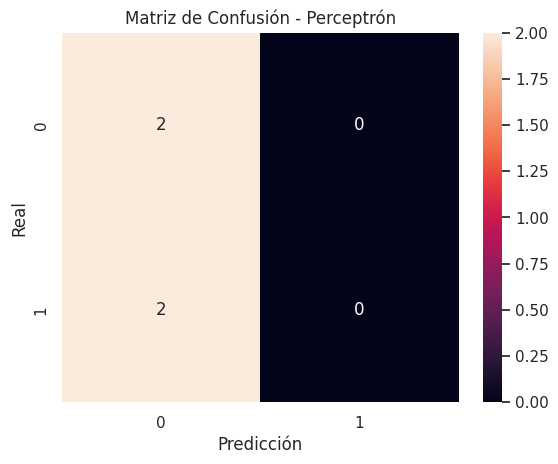

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


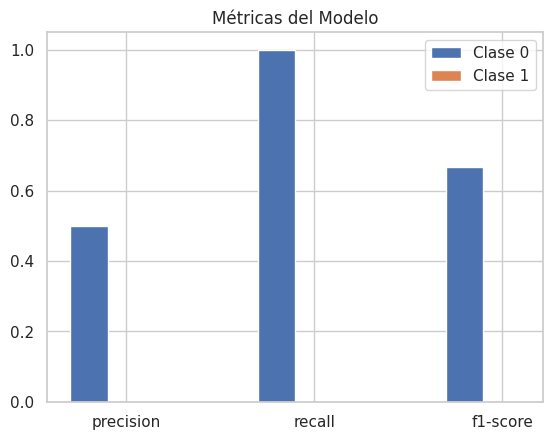


=== PRUEBA MANUAL DEL MODELO ===

Ingrese x1 (0 o 1): 0
Ingrese x2 (0 o 1): 1
👉 Resultado predicho: 0
✔ Resultado real (XOR): 1
❌ Incorrecto (limitación del perceptrón)

¿Deseas probar otro? (s/n): s

Ingrese x1 (0 o 1): 0
Ingrese x2 (0 o 1): 0
👉 Resultado predicho: 0
✔ Resultado real (XOR): 0
✅ Correcto

¿Deseas probar otro? (s/n): s

Ingrese x1 (0 o 1): 1
Ingrese x2 (0 o 1): 0
👉 Resultado predicho: 0
✔ Resultado real (XOR): 1
❌ Incorrecto (limitación del perceptrón)

¿Deseas probar otro? (s/n): n


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# =========================
# ESTILO GRÁFICO
# =========================
sns.set(style="whitegrid")

# =========================
# 1. DATOS XOR
# FASE A - (2) Datos de entrenamiento
# Aquí se definen las entradas y salidas del problema XOR
# =========================
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])

# =========================
# 2. MODELO PERCEPTRÓN
# FASE A - (1) Implementación del modelo
# Se crea un clasificador lineal de una sola capa
# =========================
modelo = Perceptron(max_iter=1000, eta0=0.1, random_state=42)

# =========================
# 3. ENTRENAMIENTO
# FASE A - (2) Entrenamiento del modelo con XOR
# El modelo aprende a partir de los datos
# =========================
modelo.fit(X, y)

# =========================
# 4. PREDICCIONES
# FASE A - (3) Evaluación inicial
# Se generan predicciones sobre los mismos datos
# =========================
y_pred = modelo.predict(X)
print("Predicciones:", y_pred)

# =========================
# 5. MÉTRICAS
# FASE A - (3) Análisis del rendimiento
# Se calcula accuracy y otras métricas
# =========================
accuracy = accuracy_score(y, y_pred)
print("\nAccuracy:", accuracy)

print("\nReporte de Clasificación:")
print(classification_report(y, y_pred, zero_division=0))

# =========================
# 6. MATRIZ DE CONFUSIÓN (BONITA)
# FASE A - (3) Visualización de errores
# Permite ver dónde falla el modelo
# =========================
cm = confusion_matrix(y, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["0","1"],
            yticklabels=["0","1"])

plt.title("Matriz de Confusión - Perceptrón")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# =========================
# 7. GRÁFICO DE MÉTRICAS
# FASE A - (3) Visualización del desempeño
# Comparación entre clases
# =========================
report = classification_report(y, y_pred, output_dict=True)

metricas = ["precision", "recall", "f1-score"]
clases = ["0", "1"]

valores = []
for c in clases:
    valores.append([
        report[c]["precision"],
        report[c]["recall"],
        report[c]["f1-score"]
    ])

valores = np.array(valores)
x = np.arange(len(metricas))

plt.figure()

for i, clase in enumerate(clases):
    plt.bar(x + i*0.2, valores[i], width=0.2, label=f'Clase {clase}')

plt.xticks(x + 0.2, metricas)
plt.title("Métricas del Modelo")
plt.legend()
plt.show()

# =========================
# 8. PRUEBA INTERACTIVA
# FASE A - (3) Validación manual
# Se ingresan nuevos datos para evaluar el modelo
# =========================
print("\n=== PRUEBA MANUAL DEL MODELO ===")

while True:
    try:
        x1 = int(input("\nIngrese x1 (0 o 1): "))
        x2 = int(input("Ingrese x2 (0 o 1): "))

        if x1 not in [0,1] or x2 not in [0,1]:
            print("⚠️ Solo se permiten valores 0 o 1")
            continue

        entrada = np.array([[x1, x2]])
        resultado = modelo.predict(entrada)

        print("👉 Resultado predicho:", resultado[0])

        # Resultado real XOR
        real = x1 ^ x2
        print("✔ Resultado real (XOR):", real)

        if resultado[0] == real:
            print("✅ Correcto")
        else:
            print("❌ Incorrecto (limitación del perceptrón)")

        continuar = input("\n¿Deseas probar otro? (s/n): ")
        if continuar.lower() != 's':
            break

    except:
        print("❌ Error: ingresa solo números válidos")

Predicciones: [0 1 1 0]

Accuracy: 1.0

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



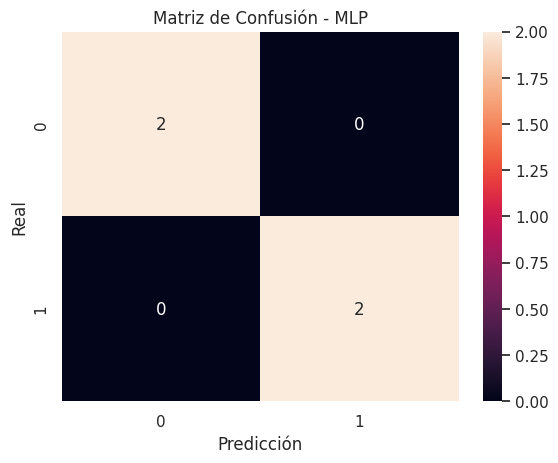

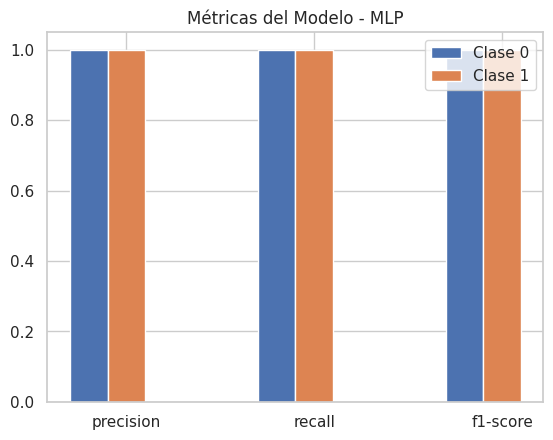


=== PRUEBA MANUAL DEL MLP ===

Ingrese x1 (0 o 1): 1
Ingrese x2 (0 o 1): 0
👉 Resultado predicho: 1
✔ Resultado real (XOR): 1
✅ Correcto

¿Deseas probar otro? (s/n): s

Ingrese x1 (0 o 1): 0
Ingrese x2 (0 o 1): 1
👉 Resultado predicho: 1
✔ Resultado real (XOR): 1
✅ Correcto

¿Deseas probar otro? (s/n): n


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# =========================
# ESTILO GRÁFICO
# =========================
sns.set(style="whitegrid")

# =========================
# DATOS XOR
# =========================
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])

# =========================
# FASE B - (1) IMPLEMENTACIÓN DEL MLP
# FASE B - (2) ARQUITECTURA (MEJORADA)
# =========================
modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(4,),   # más neuronas
    activation='tanh',         # mejor para XOR
    solver='lbfgs',            # mejor para pocos datos
    max_iter=2000,
    random_state=42
)

# =========================
# FASE B - (3) ENTRENAMIENTO
# =========================
modelo_mlp.fit(X, y)

# =========================
# PREDICCIONES
# =========================
y_pred = modelo_mlp.predict(X)
print("Predicciones:", y_pred)

# =========================
# MÉTRICAS
# =========================
accuracy = accuracy_score(y, y_pred)
print("\nAccuracy:", accuracy)

print("\nReporte de Clasificación:")
print(classification_report(y, y_pred))

# =========================
# MATRIZ DE CONFUSIÓN
# =========================
cm = confusion_matrix(y, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["0","1"],
            yticklabels=["0","1"])

plt.title("Matriz de Confusión - MLP")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# =========================
# GRÁFICO DE MÉTRICAS
# =========================
report = classification_report(y, y_pred, output_dict=True)

metricas = ["precision", "recall", "f1-score"]
clases = ["0", "1"]

valores = []
for c in clases:
    valores.append([
        report[c]["precision"],
        report[c]["recall"],
        report[c]["f1-score"]
    ])

valores = np.array(valores)
x = np.arange(len(metricas))

plt.figure()

for i, clase in enumerate(clases):
    plt.bar(x + i*0.2, valores[i], width=0.2, label=f'Clase {clase}')

plt.xticks(x + 0.2, metricas)
plt.title("Métricas del Modelo - MLP")
plt.legend()
plt.show()

# =========================
# PRUEBA INTERACTIVA
# =========================
print("\n=== PRUEBA MANUAL DEL MLP ===")

while True:
    try:
        x1 = int(input("\nIngrese x1 (0 o 1): "))
        x2 = int(input("Ingrese x2 (0 o 1): "))

        if x1 not in [0,1] or x2 not in [0,1]:
            print("⚠️ Solo se permiten valores 0 o 1")
            continue

        entrada = np.array([[x1, x2]])
        resultado = modelo_mlp.predict(entrada)

        print("👉 Resultado predicho:", resultado[0])

        real = x1 ^ x2
        print("✔ Resultado real (XOR):", real)

        if resultado[0] == real:
            print("✅ Correcto")
        else:
            print("❌ Incorrecto")

        continuar = input("\n¿Deseas probar otro? (s/n): ")
        if continuar.lower() != 's':
            break

    except:
        print("❌ Error: ingresa valores válidos")


=== TABLA COMPARATIVA ===

            Accuracy  Precision  Recall  F1-Score
Perceptrón       0.5       0.25     0.5  0.333333
MLP              1.0       1.00     1.0  1.000000


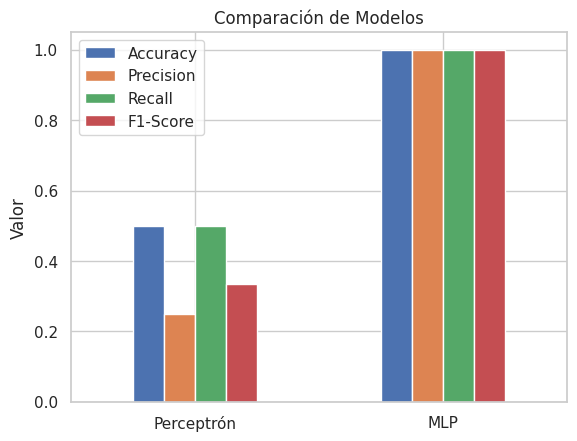

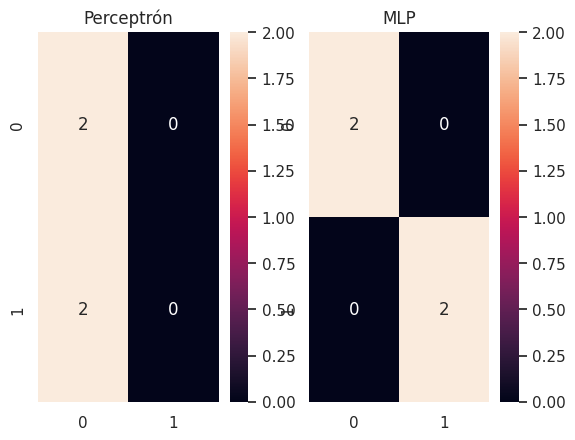

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# =========================
# FASE C - COMPARACIÓN
# =========================

# (usa los modelos ya entrenados de A y B)
# modelo -> Perceptrón
# modelo_mlp -> MLP

# Predicciones
y_pred_p = modelo.predict(X)
y_pred_mlp = modelo_mlp.predict(X)

# =========================
# FUNCIÓN PARA MÉTRICAS
# =========================
def obtener_metricas(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-Score": report["weighted avg"]["f1-score"]
    }

# Obtener métricas
metricas_p = obtener_metricas(y, y_pred_p)
metricas_mlp = obtener_metricas(y, y_pred_mlp)

# =========================
# TABLA COMPARATIVA
# =========================
df = pd.DataFrame([metricas_p, metricas_mlp],
                  index=["Perceptrón", "MLP"])

print("\n=== TABLA COMPARATIVA ===\n")
print(df)

# =========================
# GRÁFICO COMPARATIVO
# =========================
df.plot(kind='bar')
plt.title("Comparación de Modelos")
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.show()

# =========================
# MATRICES DE CONFUSIÓN
# =========================
fig, axes = plt.subplots(1, 2)

sns.heatmap(confusion_matrix(y, y_pred_p), annot=True, fmt='d',
            ax=axes[0], xticklabels=["0","1"], yticklabels=["0","1"])
axes[0].set_title("Perceptrón")

sns.heatmap(confusion_matrix(y, y_pred_mlp), annot=True, fmt='d',
            ax=axes[1], xticklabels=["0","1"], yticklabels=["0","1"])
axes[1].set_title("MLP")

plt.show()